<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Grupo_M%C3%A9xico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 21.9 MB/s eta 0:00:00


In [5]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math
from pmdarima.arima import auto_arima

#Grupo México

In [6]:
#Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01')

/tmp/ipykernel_4611/2329736698.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [7]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [8]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Análisis de la serie

##Medias Móviles

###Media Móvil Simple

In [9]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

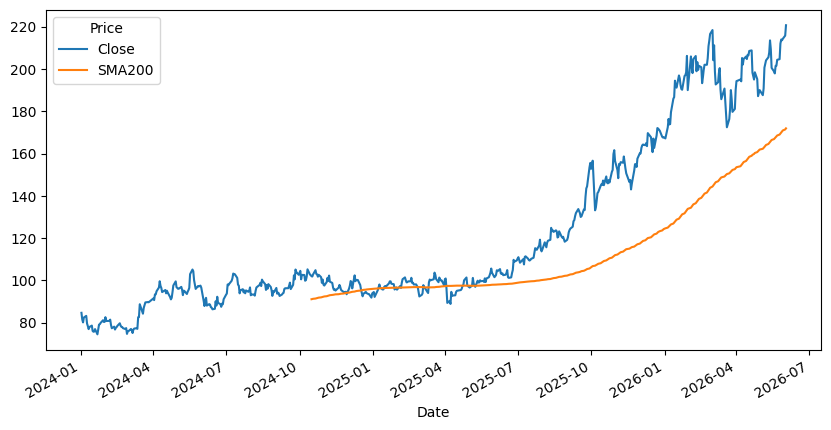

In [10]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [11]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [12]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

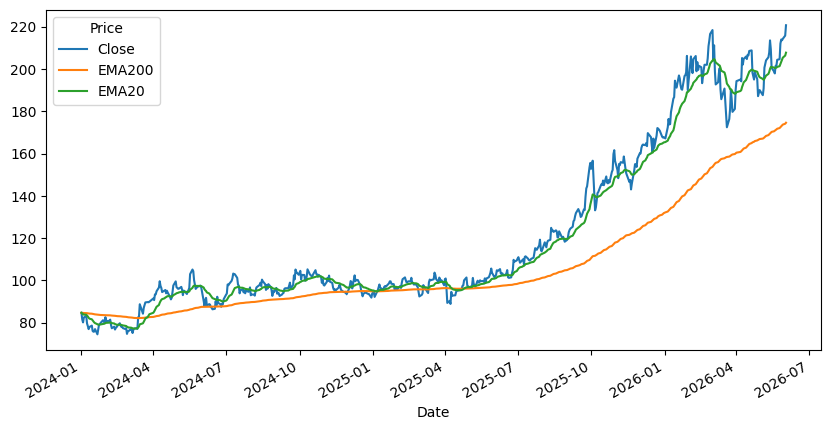

In [13]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

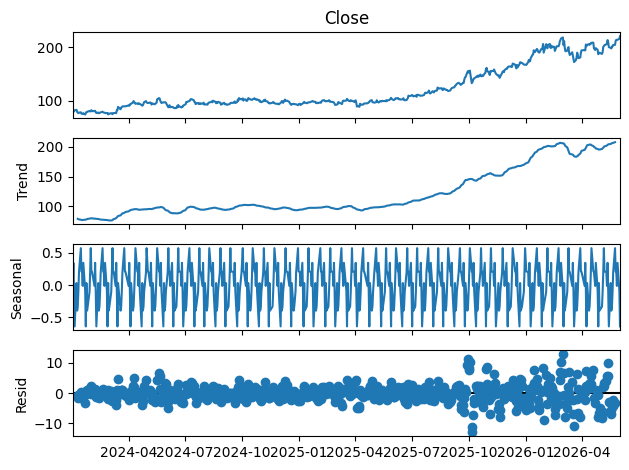

In [14]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

###Modelo Multiplicativo

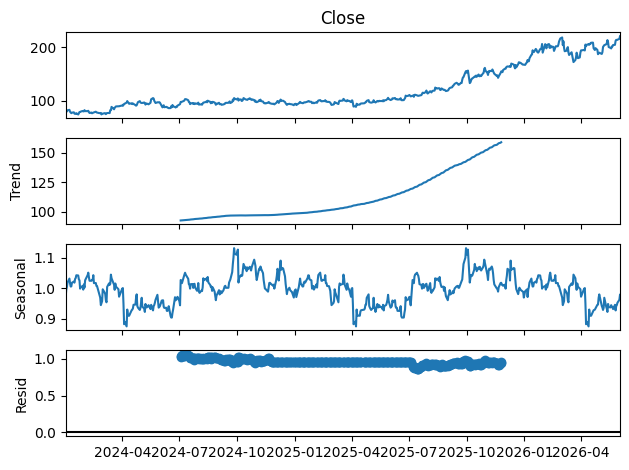

In [15]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()

In [16]:
# Seleccionar la columna de cierre y eliminar valores nulos
series = df['Close'].dropna()

In [17]:
# 2. Configurar y ejecutar la descomposición STL
# period: longitud de la estacionalidad. Para datos diarios, usualmente 365.
# robust=True ayuda a reducir la influencia de valores atípicos.
stl = STL(series, period=365, robust=True)
result = stl.fit()

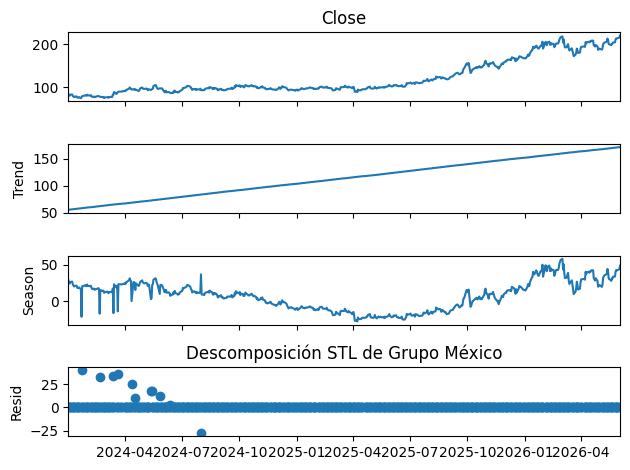

In [18]:
# 3. Visualizar los componentes
result.plot()
plt.title(f"Descomposición STL de Grupo México")
plt.tight_layout()
plt.show()

#Volatilidad

##Desviación Estándar

In [19]:
#Obtener datos
precios = df['Close']

In [20]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03   -0.037720
2024-01-04   -0.017484
2024-01-05    0.028422
2024-01-08    0.009406
                ...   
2026-05-27    0.009225
2026-05-28   -0.001717
2026-05-29    0.003225
2026-06-01    0.007161
2026-06-02    0.022449
Name: Rendimientos_Log, Length: 604, dtype: float64


In [21]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03   -0.037720
2024-01-04   -0.017484
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-05-27    0.009225
2026-05-28   -0.001717
2026-05-29    0.003225
2026-06-01    0.007161
2026-06-02    0.022449
Name: Rendimientos_Log, Length: 603, dtype: float64


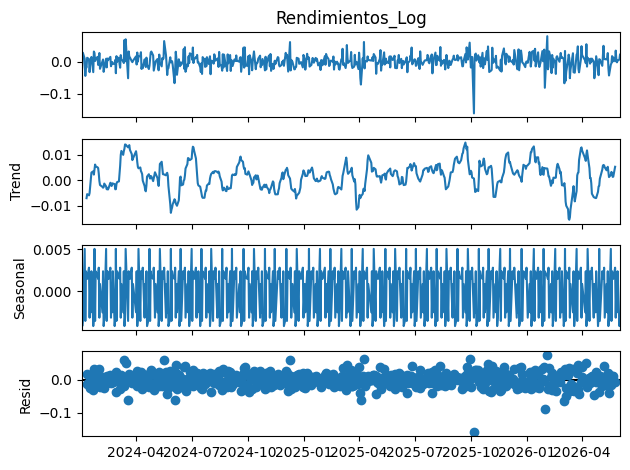

In [22]:
# Descomponer
result = seasonal_decompose(df['Rendimientos_Log'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

In [23]:
# 2. Configurar y ejecutar la descomposición STL
# period: longitud de la estacionalidad. Para datos diarios, usualmente 365.
# robust=True ayuda a reducir la influencia de valores atípicos.
stl = STL(df['Rendimientos_Log'], period=365, robust=True)
result = stl.fit()

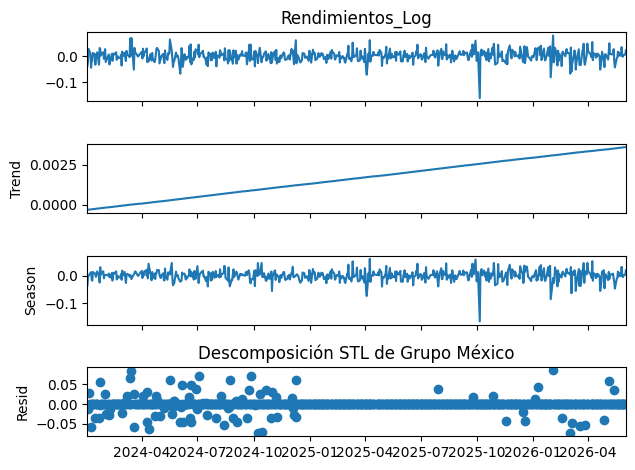

In [24]:
# 3. Visualizar los componentes
result.plot()
plt.title(f"Descomposición STL de Grupo México")
plt.tight_layout()
plt.show()

In [25]:
#Calcular la desviación estándar de los rendimientos (Volatilidad Diaria)
volatilidad_diaria = df['Rendimientos_Log'].std()

In [26]:
#Anualizar la volatilidad (multiplicando por la raíz cuadrada de 252 días hábiles al año)
volatilidad_anual = volatilidad_diaria * np.sqrt(252)

In [27]:
Volatilidad_diaria_porcentaje = volatilidad_diaria * 100
Volatilidad_anual_porcentaje = volatilidad_anual * 100

In [28]:
print(f"Volatilidad diaria: {volatilidad_diaria:.4f} = {Volatilidad_diaria_porcentaje:.4f} %")
print(f"Volatilidad anualizada: {volatilidad_anual:.4f} = {Volatilidad_anual_porcentaje:.4f} %")

Volatilidad diaria: 0.0222 = 2.2231 %
Volatilidad anualizada: 0.3529 = 35.2913 %


##Average True Range

In [29]:
#Calcular los 3 componentes del True Range (TR)
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift(1))
low_close = np.abs(df['Low'] - df['Close'].shift(1))

In [30]:
print(high_low)

Date
2024-01-03     3.811027
2024-01-04     2.643276
2024-01-05     6.381882
2024-01-08     2.570863
2024-01-09     4.200276
                ...    
2026-05-27     4.912053
2026-05-28     7.839436
2026-05-29     8.860001
2026-06-01    10.649994
2026-06-02     7.729996
Length: 603, dtype: float64


In [31]:
print(high_close)

Date
2024-01-03         NaN
2024-01-04    0.117651
2024-01-05    6.046963
2024-01-08    0.887134
2024-01-09    0.253453
                ...   
2026-05-27    2.788468
2026-05-28    1.369413
2026-05-29    3.400009
2026-06-01    5.380005
2026-06-02    8.000000
Length: 603, dtype: float64


In [32]:
print(low_close)

Date
2024-01-03         NaN
2024-01-04    2.525625
2024-01-05    0.334919
2024-01-08    1.683729
2024-01-09    3.946823
                ...   
2026-05-27    2.123585
2026-05-28    6.470023
2026-05-29    5.459991
2026-06-01    5.269989
2026-06-02    0.270004
Length: 603, dtype: float64


In [33]:
#Unir y obtener el máximo de los 3 para cada día
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = ranges.max(axis=1)

In [34]:
print(true_range)

Date
2024-01-03     3.811027
2024-01-04     2.643276
2024-01-05     6.381882
2024-01-08     2.570863
2024-01-09     4.200276
                ...    
2026-05-27     4.912053
2026-05-28     7.839436
2026-05-29     8.860001
2026-06-01    10.649994
2026-06-02     8.000000
Length: 603, dtype: float64


In [35]:
#Calcular el ATR (suavizado clásico de Wilder, n=14)
atr_period = 14
atr = true_range.copy()

In [36]:
#El primer ATR es la media simple de los primeros 14 días
atr.iloc[atr_period-1] = true_range.iloc[:atr_period].mean()

In [37]:
#Iterar para aplicar la fórmula suavizada
for i in range(atr_period, len(true_range)):
    atr.iloc[i] = (atr.iloc[i-1] * (atr_period - 1) + true_range.iloc[i]) / atr_period

df['ATR_Calculado'] = atr
print(df[['High', 'Low', 'Close', 'ATR_Calculado']].tail())

Price             High         Low       Close  ATR_Calculado
Date                                                         
2026-05-27  214.790803  209.878750  213.967163       7.177217
2026-05-28  215.336576  207.497140  213.599991       7.224518
2026-05-29  217.000000  208.139999  214.289993       7.341338
2026-06-01  219.669998  209.020004  215.830002       7.577671
2026-06-02  223.830002  216.100006  220.729996       7.607837


In [38]:
#ATR diario
atr_diario = atr.mean()
print(f"ATR diario: {atr_diario:.4f}")

ATR diario: 4.1947


In [39]:
#ATR Anualizado
atr_anualizado = atr.mean() * np.sqrt(252)
print(f"ATR anualizado: {atr_anualizado:.4f}")

ATR anualizado: 66.5894


#Parámetros (p,d,q)

##Precios Diferenciados

###Serie Estacionaria


In [40]:
#Obtener datos
precios = df['Close']

In [41]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [42]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: 0.6361
Valor p: 0.9885
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.9884713523054931)

####Diferenciando

In [43]:
# Calcular la primera diferencia del precio de cierre (columna 'Close')
differenced_prices = precios.diff().dropna()

In [44]:
# Mostrar los primeros elementos de la serie diferenciada
print(differenced_prices.head())

Date
2024-01-04   -1.412193
2024-01-05    2.308357
2024-01-08    0.778503
2024-01-09   -3.611885
2024-01-10   -1.213005
Name: Close, dtype: float64


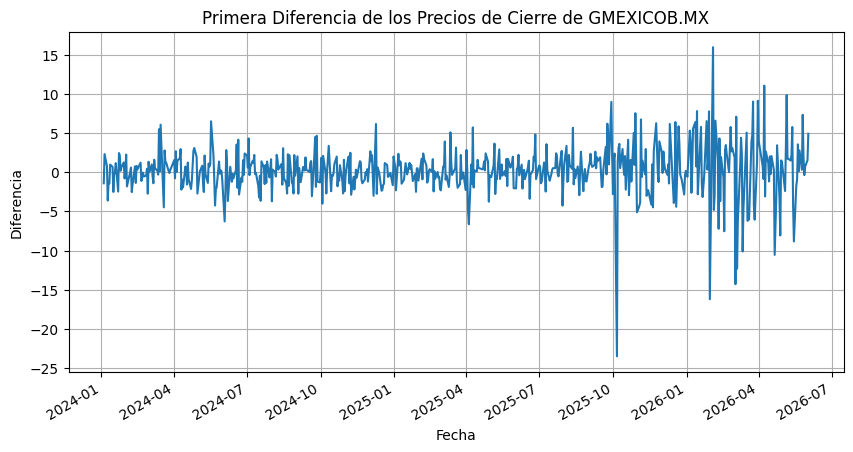

In [45]:
# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
differenced_prices.plot()
plt.title(f'Primera Diferencia de los Precios de Cierre de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

In [46]:
# Ejecutar prueba en serie diferenciada
probar_estacionariedad(differenced_prices, "Serie diferenciada")


--- Prueba ADF para: Serie diferenciada ---
Estadístico de Dickey-Fuller: -26.9905
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

###Función de Autocorrelación

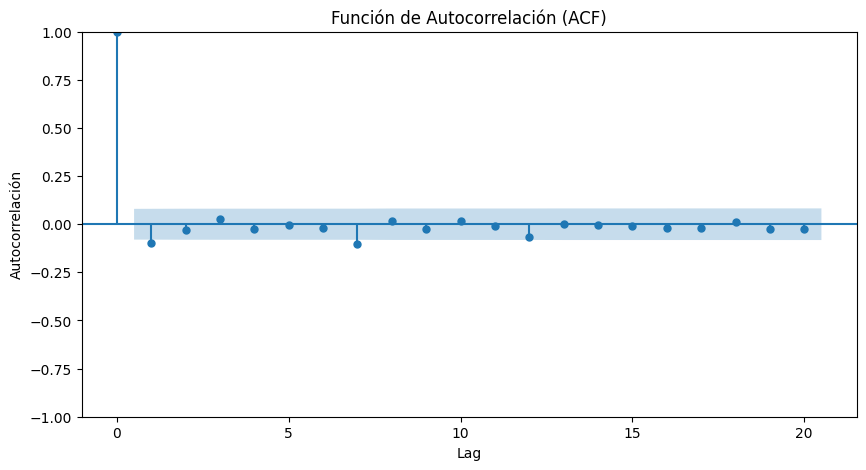

In [47]:
#Graficar la ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(differenced_prices, lags=20, ax=ax) # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial (PACF)

<Figure size 1000x500 with 0 Axes>

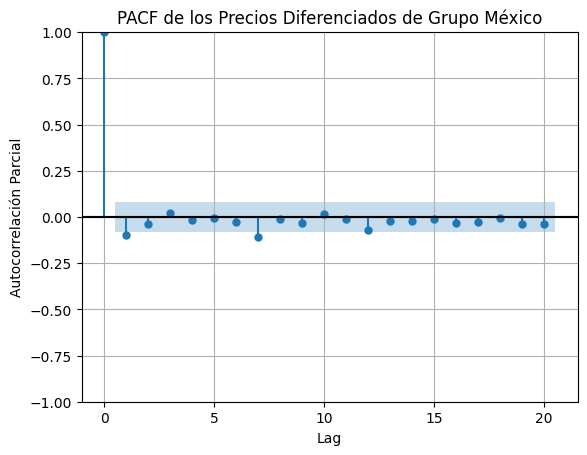

In [48]:
#Graficar la PACF
plt.figure(figsize=(10, 5))
plot_pacf(differenced_prices, lags=20, method='ywm') # method='ywm' es Yule-Walker modificado
plt.title('PACF de los Precios Diferenciados de Grupo México')
plt.xlabel('Lag')
plt.ylabel('Autocorrelación Parcial')
plt.axhline(y=0, color='k', linestyle='-')
plt.grid(True)
plt.show()

##Rendimientos Logarítmicos

In [49]:
#Cargar datos y calcular rendimientos logarítmicos
df['log_Close'] = np.log(df['Close'])

In [50]:
print(df['log_Close'])

Date
2024-01-03    4.400357
2024-01-04    4.382873
2024-01-05    4.411296
2024-01-08    4.420702
2024-01-09    4.376294
                ...   
2026-05-27    5.365823
2026-05-28    5.364105
2026-05-29    5.367330
2026-06-01    5.374491
2026-06-02    5.396940
Name: log_Close, Length: 603, dtype: float64


In [51]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada)
probar_estacionariedad(df['log_Close'], "Retornos Logarítmicos")


--- Prueba ADF para: Retornos Logarítmicos ---
Estadístico de Dickey-Fuller: 0.1272
Valor p: 0.9679
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.9678686492529568)

###Estacionariedad

In [52]:
df['rendimiento_log'] = df['log_Close'].diff().dropna()

In [53]:
print(df['rendimiento_log'])

Date
2024-01-03         NaN
2024-01-04   -0.017484
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-05-27    0.009225
2026-05-28   -0.001717
2026-05-29    0.003225
2026-06-01    0.007161
2026-06-02    0.022449
Name: rendimiento_log, Length: 603, dtype: float64


In [54]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada)
probar_estacionariedad(df['rendimiento_log'], "Retornos Logarítmicos Diferenciados")


--- Prueba ADF para: Retornos Logarítmicos Diferenciados ---
Estadístico de Dickey-Fuller: -26.8091
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

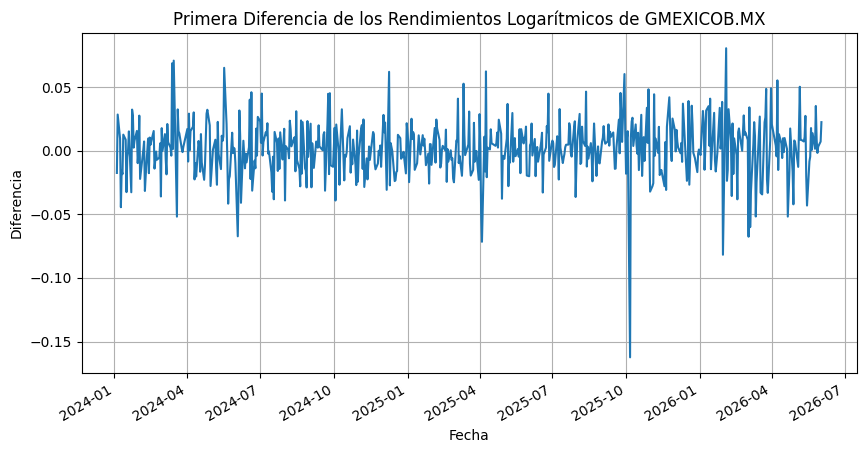

In [55]:
# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
df['rendimiento_log'].plot()
plt.title(f'Primera Diferencia de los Rendimientos Logarítmicos de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

###Función de Autocorrelación

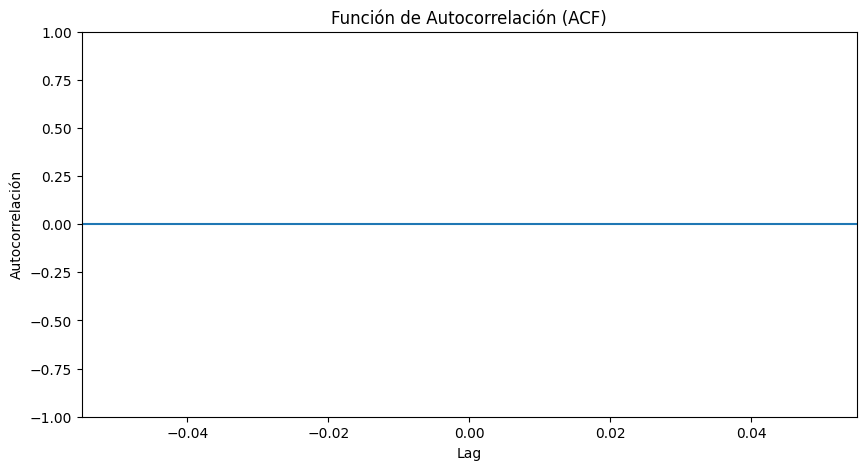

In [56]:
#Gráfica ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(df['rendimiento_log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial

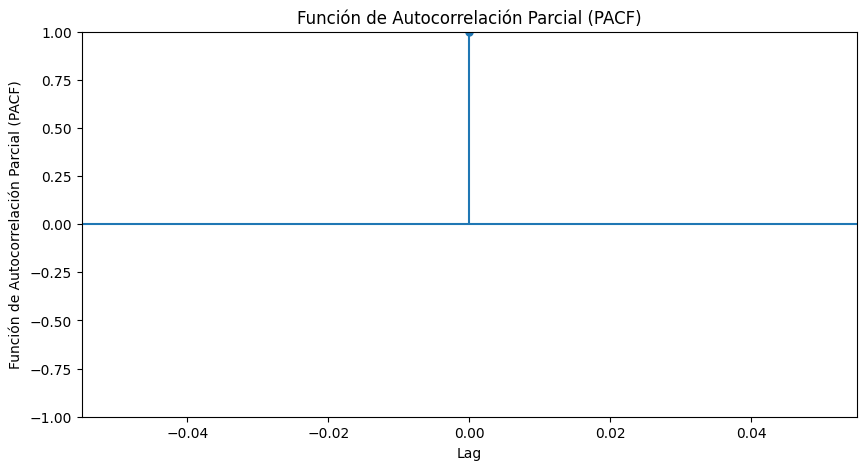

In [57]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(df['rendimiento_log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Función de Autocorrelación Parcial (PACF)")
ax.set_title("Función de Autocorrelación Parcial (PACF)")
plt.show()

#ARIMA

In [58]:
# Fit the ARIMA model
# Initial ARIMA Model parameters
p, d, q = 0,1,0
model = ARIMA(df['rendimiento_log'], order=(p, d, q))
model_fit = model.fit()
model_summary = model_fit.summary()
model_summary

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        rendimiento_log   No. Observations:                  603
Model:                 ARIMA(0, 1, 0)   Log Likelihood                1193.967
Date:                Wed, 03 Jun 2026   AIC                          -2385.934
Time:                        00:06:02   BIC                          -2381.534
Sample:                             0   HQIC                         -2384.222
                                - 603                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0011   3.65e-05     29.419      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                 173.32   Jarque-Bera (JB):               356.60
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.48   Skew:                            -0.03
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.77
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

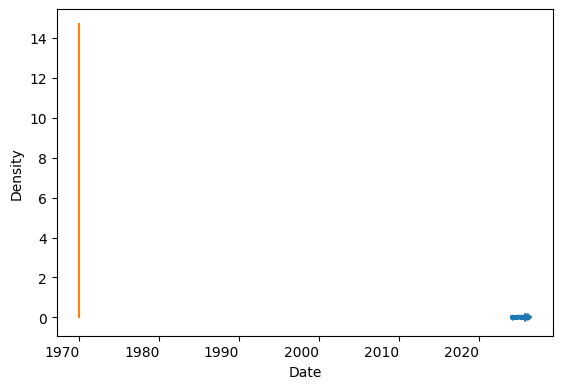

In [59]:
# plot residual errors
residuals = model_fit.resid
residuals.plot()
residuals.plot(kind='kde')
plt.show()

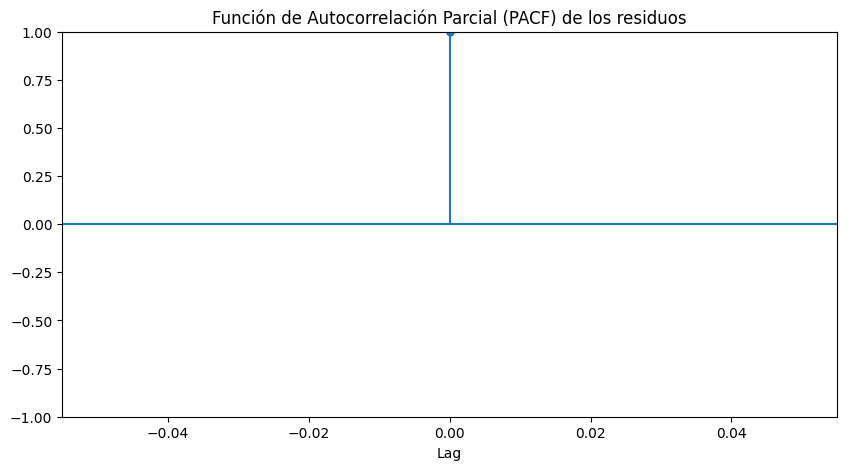

In [60]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(residuals, lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_title("Función de Autocorrelación Parcial (PACF) de los residuos")
plt.show()

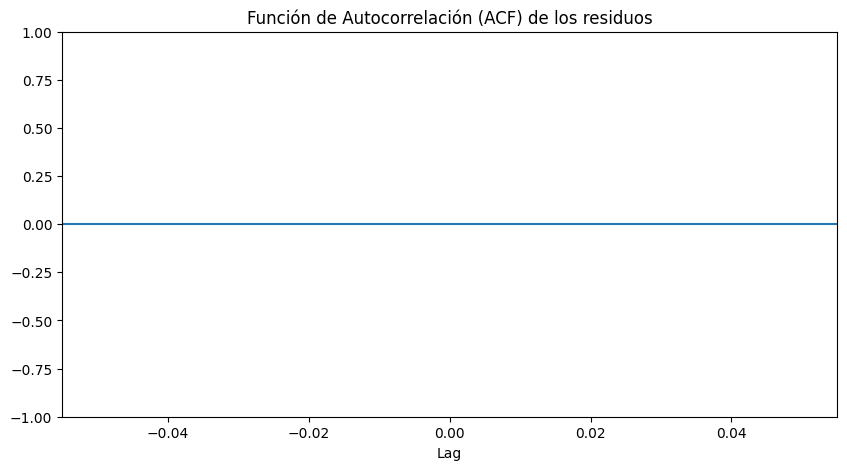

In [61]:
#Graficar la ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(residuals, lags=20, ax=ax) # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_title("Función de Autocorrelación (ACF) de los residuos")
plt.show()

In [62]:
# 2. División de datos en entrenamiento y prueba
train_size = int(len(series) * 0.8)
train, test = series.iloc[:train_size], series.iloc[train_size:]

In [63]:
# 3. Ajustar modelo ARIMA(0,1,0)
# order=(p, d, q) -> (0, 1, 0) significa:
# p=0 (sin término autorregresivo), d=1 (diferenciación para estacionariedad), q=0 (sin término de media móvil)
model = ARIMA(train, order=(0, 1, 0))
model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [64]:
# 4. Generar predicciones para el conjunto de prueba
# forecast(steps=n) predice los siguientes n pasos
forecast = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [65]:
# 5. Evaluación y Visualización
rmse = math.sqrt(mean_squared_error(test, forecast))
print(f"RMSE del modelo ARIMA(0,1,0): {rmse:.4f}")

RMSE del modelo ARIMA(0,1,0): 35.8019


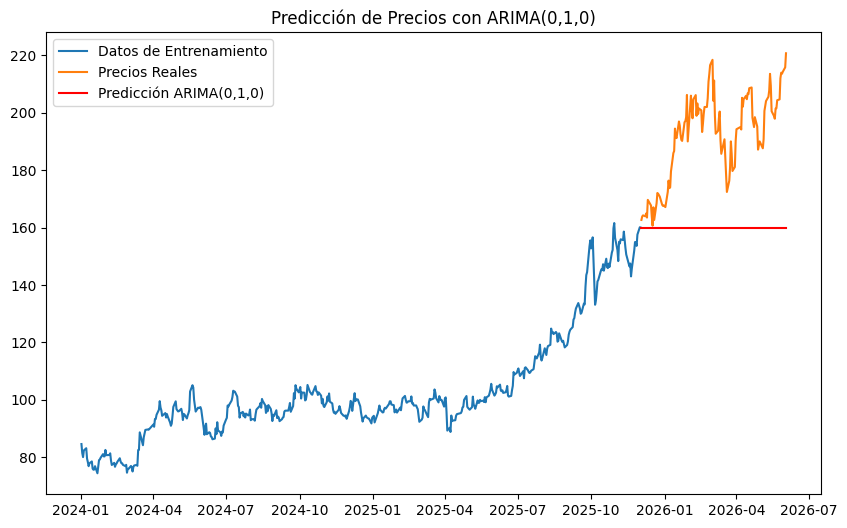

In [66]:
plt.figure(figsize=(10, 6))
plt.plot(train.index, train, label='Datos de Entrenamiento')
plt.plot(test.index, test, label='Precios Reales')
plt.plot(test.index, forecast, label='Predicción ARIMA(0,1,0)', color='red')
plt.legend()
plt.title('Predicción de Precios con ARIMA(0,1,0)')
plt.show()

In [67]:
##Ejemplo básico
model = auto_arima(
    df['rendimiento_log'].dropna(),  # Serie temporal, asegurándose de que no haya NaN
    start_p=0,          # Orden AR inicial
    start_q=0,          # Orden MA inicial
    max_p=5,            # Máximo orden AR
    max_q=5,            # Máximo orden MA
    m=1,                # Periodo estacional (1 si no hay estacionalidad)
    seasonal=False,     # True si la serie es estacional
    stepwise=True,      # Usa búsqueda paso a paso para mayor velocidad
    trace=True          # Muestra el proceso de selección
)

# Resumen del modelo encontrado
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-2872.114, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-2874.464, Time=0.07 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-2874.558, Time=0.11 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-2872.610, Time=0.19 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-2872.590, Time=0.49 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-2870.639, Time=1.83 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-2876.632, Time=1.16 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-2873.460, Time=0.15 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-2874.852, Time=0.23 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-2874.765, Time=0.26 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-2876.453, Time=0.36 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-2872.758, Time=0.79 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0] intercept
Total fit time: 5.714 seconds
                               SARIMAX Results                              

#Monte Carlo

In [68]:
#Calcular los retornos
retornos = df['Close'].pct_change().dropna()

In [70]:
#Calculamos la media
media_retornos = retornos.mean()
print("media de los retornos =", media_retornos)


media de los retornos = 0.0019019514252251119


In [71]:
#Calculamos la desviación estándar
desviacion_retornos = retornos.std()
print("desviación estándar de los retornos = ", desviacion_retornos)

desviación estándar de los retornos =  0.02209075707451002


In [74]:
#Para cada día de predicción, generaremos un retorno aleatorio utilizando la media y desviación estándar calculadas.
retorno_aleatorio = np.random.normal(media_retornos, desviacion_retornos)
print("retorno aleatorio = ", retorno_aleatorio)

retorno aleatorio =  0.044182263245580236


In [94]:
# Usaremos este retorno para calcular el precio del activo para ese día.
# Inicializar la lista de precios simulados con el último precio de cierre
Precio_simulado = [df['Close'].iloc[-1]]

# Simular 100 días de predicción
for _ in range(100):
  Precio_simulado.append(Precio_simulado[-1] * (1 + retorno_aleatorio))

print(" ".join(map(str, Precio_simulado)))

220.72999572753906 230.48234650496897 240.66557821171054 251.29872814241008 262.4016747024775 273.9951745702635 286.1009015011456 298.741486846067 311.940561860276 325.72280188136085 340.11397245917107 355.14097752386215 370.8319096821141 387.21610273555046 404.32418651954015 422.18814416490153 440.84137188955816 460.31874143192533 480.6566652427448 501.89316455724247 524.0679404748679 547.2224481794975 571.3999744388549 596.6457185280301 623.0068767283839 650.532730559804 679.2747389112634 709.2866342419136 740.6245230325613 773.3469906753182 807.5152109975123 843.1930606246146 880.4472383959778 919.347390056633 959.9662384582522 1002.379719512684 1046.6671241522242 1092.9112465620121 1141.1985389616702 1191.6192732255463 1244.2677096437044 1299.2422731391578 1356.645737270778 1416.5854163658696 1479.1733661415963 1544.5265931903152 1612.7672737204489 1684.0229819618223 1758.4269286624665 1836.1182101227487 1917.2420682323955 2001.9501619965397 2090.4008510584026 2182.75949174865 2279

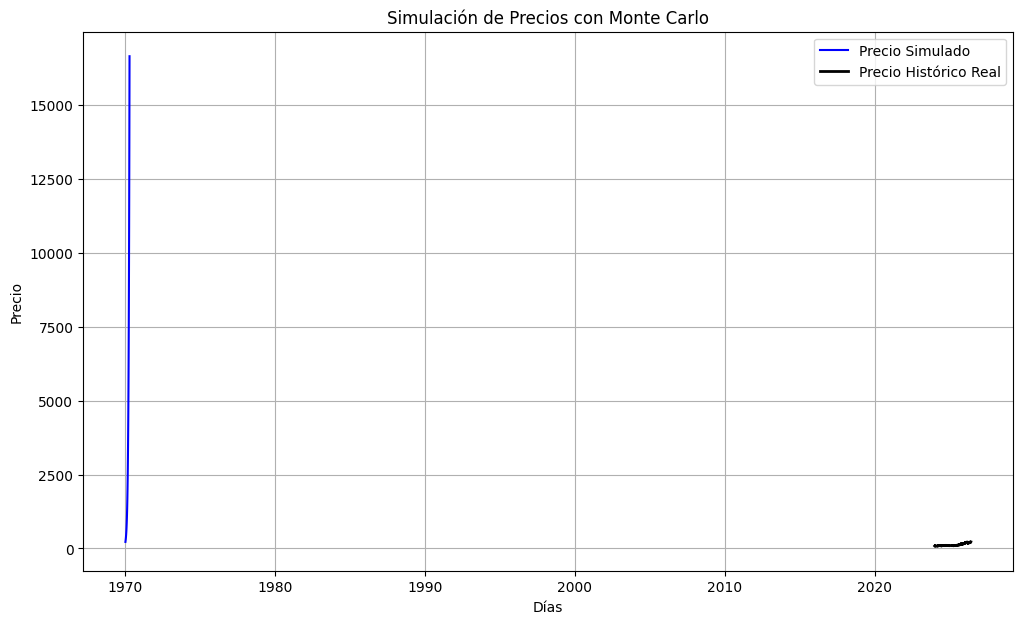

In [98]:
plt.figure(figsize=(12, 7))
plt.plot(Precio_simulado, label='Precio Simulado', color='blue')
plt.plot(df['Close'], label='Precio Histórico Real', color='black', linewidth=2)
plt.title('Simulación de Precios con Monte Carlo')
plt.xlabel('Días')
plt.ylabel('Precio')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Definir el número de simulaciones (escenarios) y el número de días a proyectar
num_simulations = 100 # Número de escenarios Monte Carlo
num_days_to_project = 100 # Número de días en el futuro para cada simulación

# Obtener el último precio de cierre del DataFrame
last_known_price = df['Close'].iloc[-1]

# Lista para almacenar todos los escenarios de precios simulados
monte_carlo_simulations = []

for _ in range(num_simulations):
    # Para cada simulación, empezar con el último precio conocido
    current_scenario_prices = [last_known_price]
    for _ in range(num_days_to_project):
        # Generar un retorno aleatorio basado en la media y desviación estándar
        daily_return = np.random.normal(media_retornos, desviacion_retornos)
        # Calcular el siguiente precio
        next_price = current_scenario_prices[-1] * (1 + daily_return)
        current_scenario_prices.append(next_price)
    monte_carlo_simulations.append(current_scenario_prices)

# Convertir la lista de simulaciones en un DataFrame para facilitar el análisis
# Transponer el DataFrame para que cada columna sea un escenario y las filas sean los días
monte_carlo_simulations_df = pd.DataFrame(monte_carlo_simulations).T

print(f"Se han generado {num_simulations} escenarios de precios simulados, cada uno con {num_days_to_project} días de proyección.")
print(monte_carlo_simulations_df.head())
print(monte_carlo_simulations_df.tail())

Se han generado 100 escenarios de precios simulados, cada uno con 100 días de proyección.
           0           1           2           3           4           5   \
0  216.009995  216.009995  216.009995  216.009995  216.009995  216.009995   
1  221.780383  216.267892  217.777082  217.727463  218.681545  206.022081   
2  221.188050  209.668477  226.879933  214.195041  218.556325  214.089044   
3  217.736909  213.180607  228.733116  223.262681  218.003731  213.465119   
4  224.292382  214.738626  230.039095  220.034143  220.082121  210.886245   

           6           7           8           9   ...          90  \
0  216.009995  216.009995  216.009995  216.009995  ...  216.009995   
1  216.260146  219.870633  219.180760  213.617549  ...  218.352895   
2  217.454357  224.773655  215.598737  205.533156  ...  218.604964   
3  211.471692  225.478980  222.549594  202.595669  ...  221.612994   
4  202.815180  224.661038  215.885666  201.623178  ...  226.091485   

           91          92 

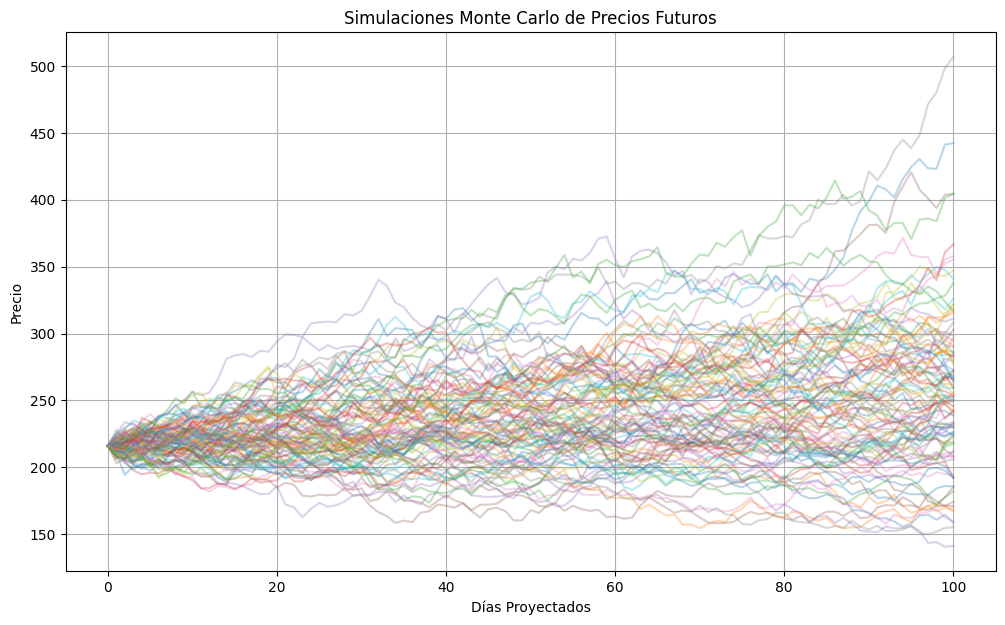

In [ ]:
plt.figure(figsize=(12, 7))

# Plotear cada simulación
for i in range(monte_carlo_simulations_df.shape[1]):
    plt.plot(monte_carlo_simulations_df.iloc[:, i], alpha=0.3)

# Opcional: Graficar el precio real hasta la fecha de inicio de la simulación
# Assuming 'df' and 'last_known_price' are available from previous cells
# plt.plot(df['Close'], label='Precio Histórico Real', color='black', linewidth=2)

# Añadir etiquetas y título
plt.title('Simulaciones Monte Carlo de Precios Futuros')
plt.xlabel('Días Proyectados')
plt.ylabel('Precio')
plt.grid(True)

# Ajustar los límites del eje y para una mejor visualización si es necesario
# plt.ylim(min_price, max_price) # descomentar y definir min/max si se desea

plt.show()

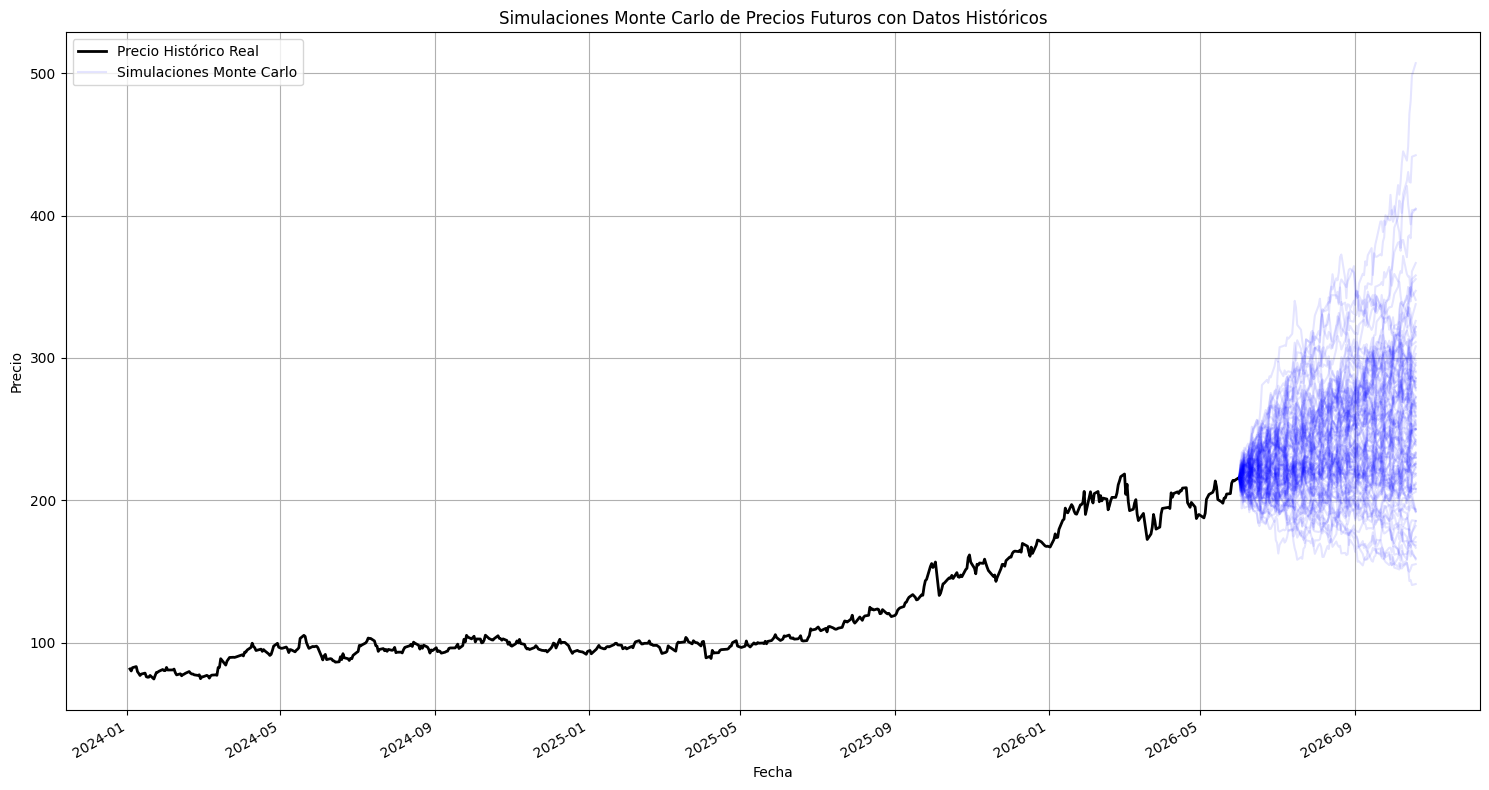

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

plt.figure(figsize=(15, 8))

# Plotear los precios históricos
plt.plot(df['Close'].index, df['Close'], label='Precio Histórico Real', color='black', linewidth=2)

# Crear un índice de tiempo para las simulaciones que continúe después de los datos históricos
last_historical_date = df['Close'].index[-1]
forecast_dates = pd.date_range(start=last_historical_date, periods=num_days_to_project + 1, freq='B')[1:] # 'B' for business day

# Asegurarse de que el DataFrame de simulaciones tiene el mismo número de filas que forecast_dates + 1 (para incluir el last_known_price)
# monte_carlo_simulations_df ya incluye el last_known_price en la fila 0, por lo que su longitud es num_days_to_project + 1.
# El forecast_dates debe tener la misma longitud que las filas de monte_carlo_simulations_df excluyendo la primera (last_known_price)

# Plotear cada simulación
for i in range(monte_carlo_simulations_df.shape[1]):
    # Usar last_historical_date para la primera fila de la simulación y luego forecast_dates para las siguientes
    full_simulation_dates = [last_historical_date] + list(forecast_dates)
    plt.plot(full_simulation_dates, monte_carlo_simulations_df.iloc[:, i], alpha=0.1, color='blue')

# Añadir etiquetas y título
plt.title('Simulaciones Monte Carlo de Precios Futuros con Datos Históricos')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.grid(True)
plt.legend(['Precio Histórico Real', 'Simulaciones Monte Carlo'], loc='upper left')

# Formato del eje x para que las fechas sean legibles
plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()

Tamaño del conjunto de entrenamiento: 481
Tamaño del conjunto de prueba: 121
Último precio conocido en entrenamiento: 160.13
Media de retornos de entrenamiento: 0.0016
Desviación estándar de retornos de entrenamiento: 0.0210
Número de días a proyectar (igual al tamaño del set de prueba): 121


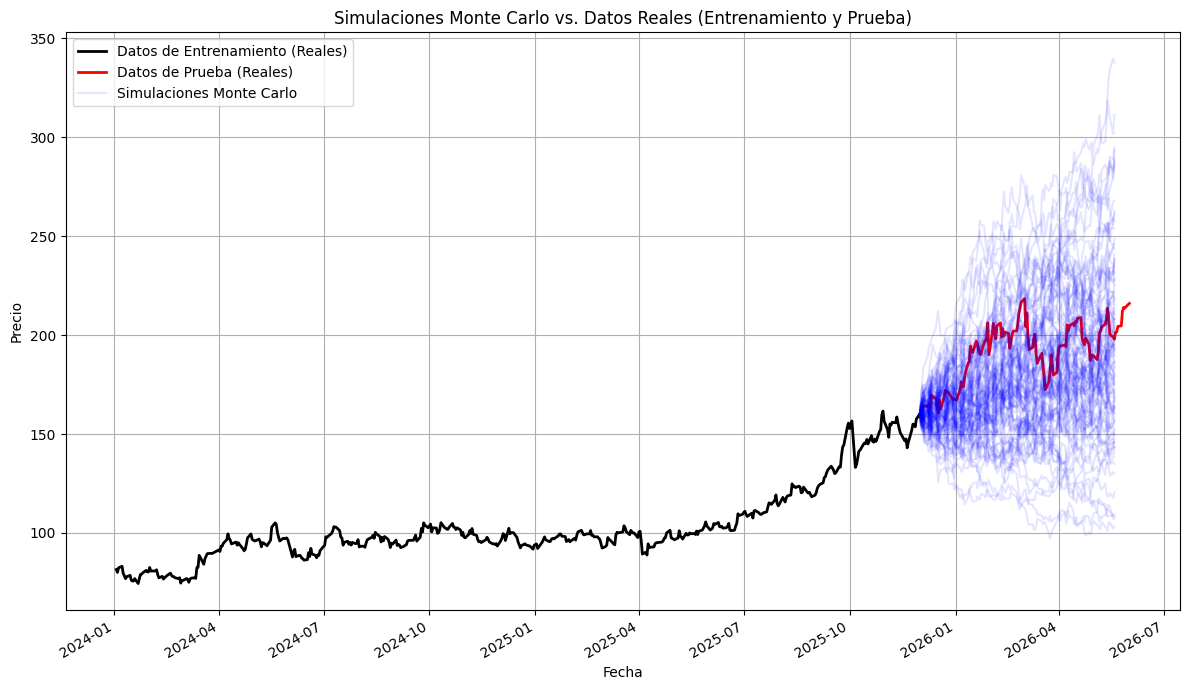

In [ ]:
# 1. Definir el punto de división para entrenamiento y prueba
# Usaremos un 80% de los datos para entrenamiento y el 20% restante para prueba
split_ratio = 0.8
split_index = int(len(df['Close']) * split_ratio)

train_series = df['Close'].iloc[:split_index]
test_series = df['Close'].iloc[split_index:]

print(f"Tamaño del conjunto de entrenamiento: {len(train_series)}")
print(f"Tamaño del conjunto de prueba: {len(test_series)}")

# 2. Recalcular los parámetros de la simulación de Monte Carlo usando SOLO los datos de entrenamiento
train_returns = train_series.pct_change().dropna()
media_retornos_train = train_returns.mean()
desviacion_retornos_train = train_returns.std()

last_known_price_train = train_series.iloc[-1]
num_days_to_project_mc = len(test_series)

print(f"Último precio conocido en entrenamiento: {last_known_price_train:.2f}")
print(f"Media de retornos de entrenamiento: {media_retornos_train:.4f}")
print(f"Desviación estándar de retornos de entrenamiento: {desviacion_retornos_train:.4f}")
print(f"Número de días a proyectar (igual al tamaño del set de prueba): {num_days_to_project_mc}")

# 3. Ejecutar la simulación de Monte Carlo
num_simulations_comparison = 100 # Número de escenarios
monte_carlo_simulations_comparison = []

for _ in range(num_simulations_comparison):
    current_scenario_prices = [last_known_price_train]
    for _ in range(num_days_to_project_mc):
        daily_return = np.random.normal(media_retornos_train, desviacion_retornos_train)
        next_price = current_scenario_prices[-1] * (1 + daily_return)
        current_scenario_prices.append(next_price)
    monte_carlo_simulations_comparison.append(current_scenario_prices)

monte_carlo_simulations_comparison_df = pd.DataFrame(monte_carlo_simulations_comparison).T

# 4. Crear un índice de tiempo para las proyecciones que coincida con el conjunto de prueba
mc_forecast_dates = pd.date_range(start=train_series.index[-1], periods=num_days_to_project_mc + 1, freq='B')[1:]

# 5. Visualizar los resultados: entrenamiento, prueba y simulaciones
plt.figure(figsize=(12, 7)) # Reduced figure size

# Plotear los datos de entrenamiento
plt.plot(train_series.index, train_series, label='Datos de Entrenamiento (Reales)', color='black', linewidth=2)

# Plotear los datos de prueba (los valores reales para comparar)
plt.plot(test_series.index, test_series, label='Datos de Prueba (Reales)', color='red', linewidth=2)

# Plotear cada simulación de Monte Carlo
for i in range(monte_carlo_simulations_comparison_df.shape[1]):
    # Las fechas de la simulación deben incluir el último punto de entrenamiento como inicio
    full_simulation_dates_mc = [train_series.index[-1]] + list(mc_forecast_dates)
    plt.plot(full_simulation_dates_mc, monte_carlo_simulations_comparison_df.iloc[:, i], alpha=0.1, color='blue')

plt.title('Simulaciones Monte Carlo vs. Datos Reales (Entrenamiento y Prueba)')
plt.xlabel('Fecha')
plt.ylabel('Precio')
plt.grid(True)
plt.legend(['Datos de Entrenamiento (Reales)', 'Datos de Prueba (Reales)', 'Simulaciones Monte Carlo'], loc='upper left')

plt.gcf().autofmt_xdate()
plt.tight_layout()
plt.show()